In [60]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

In [62]:
# Path file segy
filename = "Model/Marmousi_II_MODEL_P-WAVE_VELOCITY_1.25m.segy"

with segyio.open(filename, "r", ignore_geometry=True) as f:
    f.mmap()  # memory map untuk performa
    n_traces = f.tracecount
    n_samples = f.samples.size

    # Inisialisasi array (n_samples, n_traces) = (depth, lateral)
    velocity = np.zeros((n_samples, n_traces))

    # Baca trace satu per satu
    for i in range(n_traces):
        velocity[:, i] = f.trace[i]

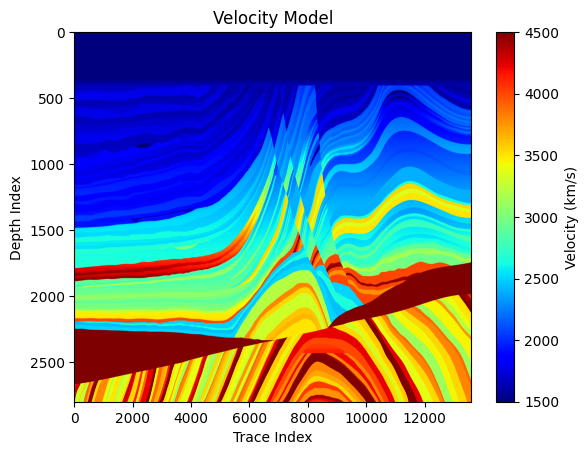

In [63]:
plt.imshow(velocity, cmap='jet', aspect='auto', origin='upper', vmin=1500, vmax=4500)
plt.colorbar(label='Velocity (km/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()

In [64]:
velocity.shape

(2801, 13601)

In [65]:
data = velocity/1000

print("Shape:", data.shape)             # Dimensi (baris, kolom)
print("Tipe data:", data.dtype)         # Tipe elemen
print("Mean:", np.mean(data))           # Rata-rata seluruh elemen
print("Median:", np.median(data))       # Median
print("Standard deviation:", np.std(data))  # Standar deviasi
print("Min:", np.min(data))
print("Max:", np.max(data))
print("Sum:", np.sum(data))

Shape: (2801, 13601)
Tipe data: float64
Mean: 2.6717932820440553
Median: 2.5
Standard deviation: 0.9737683653068475
Min: 1.028
Max: 4.7
Sum: 101785708.26185644


In [66]:
from skimage.measure import block_reduce

# velocity is a 2D array with shape (nz, nx) and grid spacing 1.25 m
# we want new grid spacing 12.5 m, so reduce by factor 10

factor = 10
velocity_downsampled = block_reduce(data, block_size=(factor, factor), func=np.max)

In [67]:
print("Shape:", velocity_downsampled.shape)             # Dimensi (baris, kolom)
print("Tipe data:", velocity_downsampled.dtype)         # Tipe elemen
print("Mean:", np.mean(velocity_downsampled))           # Rata-rata seluruh elemen
print("Median:", np.median(velocity_downsampled))       # Median
print("Standard deviation:", np.std(velocity_downsampled))  # Standar deviasi
print("Min:", np.min(velocity_downsampled))
print("Max:", np.max(velocity_downsampled))
print("Sum:", np.sum(velocity_downsampled))

Shape: (281, 1361)
Tipe data: float64
Mean: 2.7070945343510964
Median: 2.51478125
Standard deviation: 0.9893275502252924
Min: 1.028
Max: 4.7
Sum: 1035303.9408117676


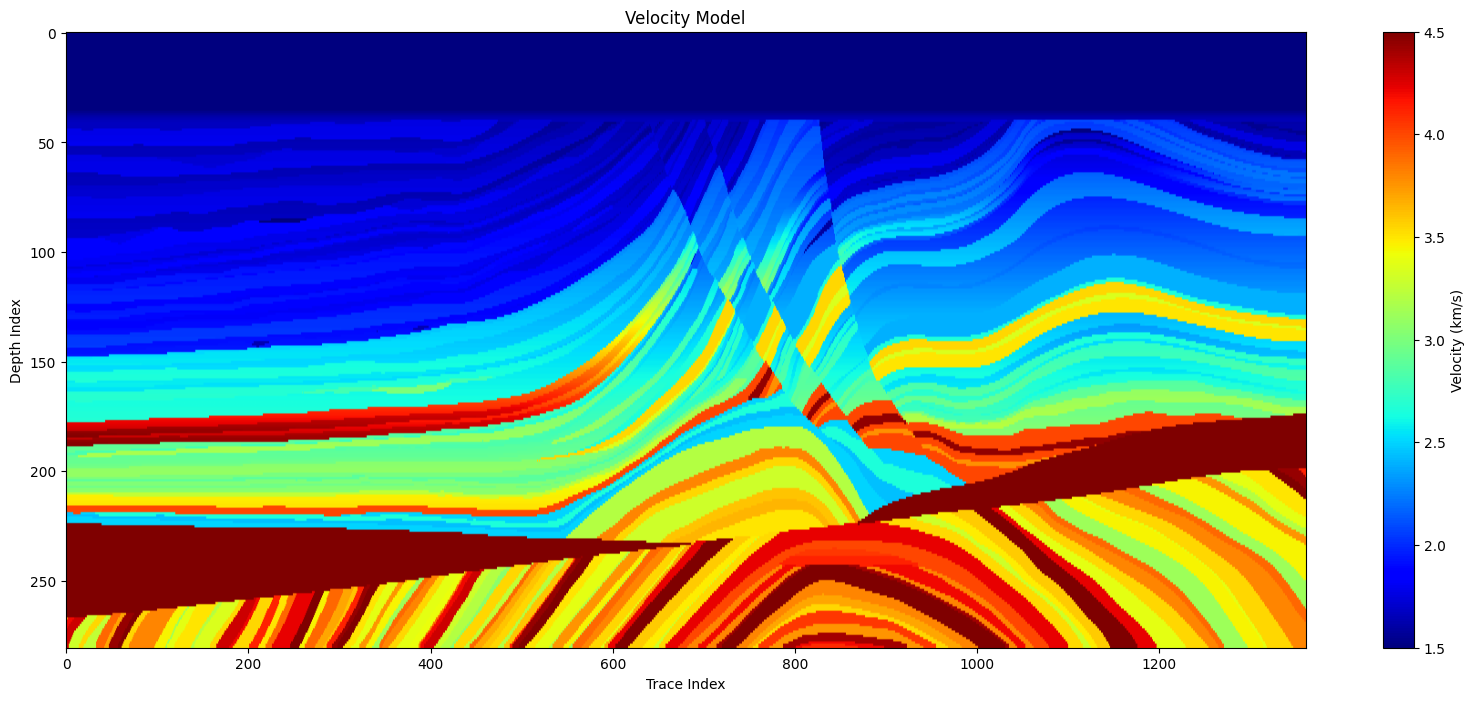

In [68]:
plt.figure(figsize=(20,8))
plt.imshow(velocity_downsampled, cmap='jet', aspect='auto', origin='upper', vmin=1.5, vmax=4.5)
plt.colorbar(label='Velocity (km/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()

In [69]:
velocity_cropped = velocity_downsampled.T[:1317,:]   #['v'].T[100:300]
#vp0 = gaussian_filter(vp, 3) #velocity model intial

print("Shape:", velocity_cropped.shape)             # Dimensi (baris, kolom)
print("Tipe data:", velocity_cropped.dtype)         # Tipe elemen
print("Mean:", np.mean(velocity_cropped))           # Rata-rata seluruh elemen
print("Median:", np.median(velocity_cropped))       # Median
print("Standard deviation:", np.std(velocity_cropped))  # Standar deviasi
print("Min:", np.min(velocity_cropped))
print("Max:", np.max(velocity_cropped))
print("Sum:", np.sum(velocity_cropped))

Shape: (1317, 281)
Tipe data: float64
Mean: 2.7039340270107637
Median: 2.51178125
Standard deviation: 0.9902385927628945
Min: 1.028
Max: 4.7
Sum: 1000663.7929140624


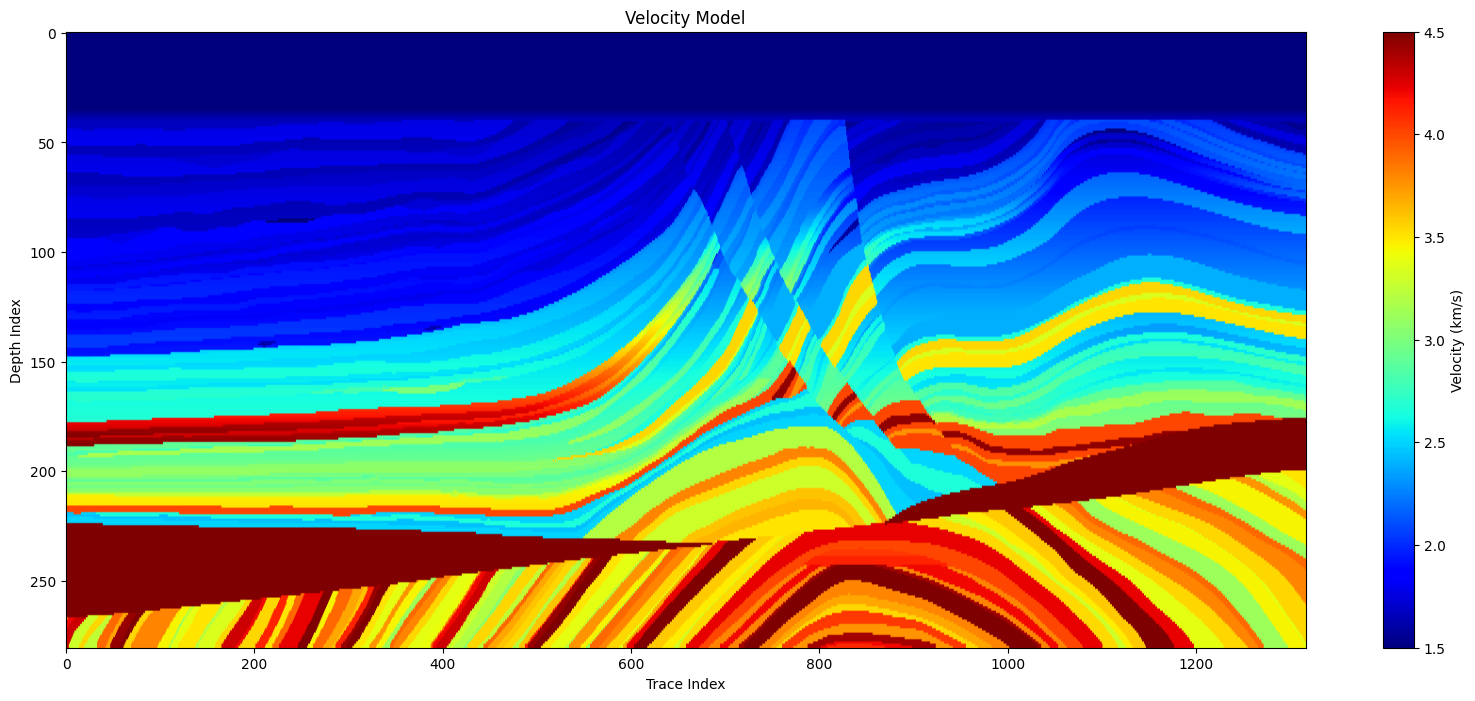

In [70]:
plt.figure(figsize=(20,8))
plt.imshow(velocity_cropped.T, cmap='jet', aspect='auto', origin='upper', vmin=1.5, vmax=4.5)
plt.colorbar(label='Velocity (km/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()

In [71]:
np.savetxt('Model/Marmousi-12_5.txt', velocity_cropped, fmt='%.4f')

In [72]:
cek_vel = np.loadtxt('Model/Marmousi-12_5.txt')

print("Shape:", cek_vel.shape)             # Dimensi (baris, kolom)
print("Tipe data:", cek_vel.dtype)         # Tipe elemen
print("Mean:", np.mean(cek_vel))           # Rata-rata seluruh elemen
print("Median:", np.median(cek_vel))       # Median
print("Standard deviation:", np.std(cek_vel))  # Standar deviasi
print("Min:", np.min(cek_vel))
print("Max:", np.max(cek_vel))
print("Sum:", np.sum(cek_vel))

Shape: (1317, 281)
Tipe data: float64
Mean: 2.703933759460869
Median: 2.5118
Standard deviation: 0.9902387663233377
Min: 1.028
Max: 4.7
Sum: 1000663.6939000001


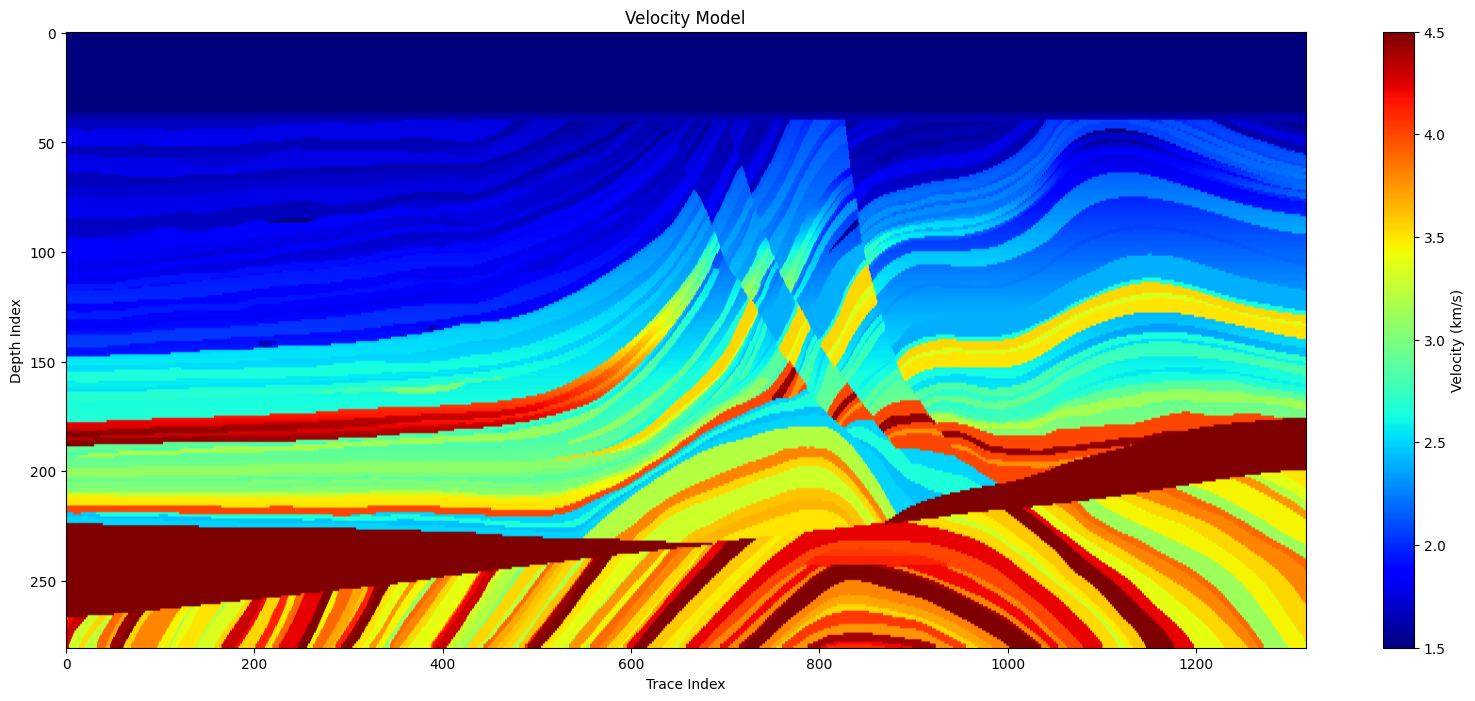

In [73]:
plt.figure(figsize=(20,8))
plt.imshow(cek_vel.T, cmap='jet', aspect='auto', origin='upper', vmin=1.5, vmax=4.5)
plt.colorbar(label='Velocity (km/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()